# Base Model (Pre-Reconciliation)

This notebook builds the base model using spend and impressions only.
No Granger causality or reconciliation is applied yet.

In [20]:
import pandas as pd
import numpy as np
import os

import tensorflow as tf
import tensorflow_probability as tfp

from meridian import constants
from meridian.data import data_frame_input_data_builder
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.analysis import summarizer
 #from meridian.analysis import reviewer 
 #from meridian.analysis import optimizer

In [21]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/pstat197/BlueAlpha3-Synergy-Analysis/refs/heads/meridian_modeling/data/monthly_mocha.csv"
)

# Remove all-zero columns
df = df.loc[:, (df != 0).any()]

df.head()

,date,subscriptions,meta_spend,meta_impressions,google_spend,google_impressions,snapchat_spend,snapchat_impressions,tiktok_spend,tiktok_impressions,moloco_spend,moloco_impressions,liveintent_spend,liveintent_impressions,beehiiv_spend,beehiiv_impressions,amazon_spend,amazon_impressions
0,8/4/25,15540,91538.06648,16572258,116667.9945,6473132,94750.04035,3420454,0.0,0,6564.524233,367206,37766.44904,371854,18190.10332,181901,0.0,0
1,7/28/25,14525,93840.18612,25300600,180486.9558,9487127,99447.23218,3235285,0.0,0,18111.083980,820589,38543.27888,347850,20063.91811,200639,0.0,0
2,7/21/25,16880,48403.06780,14099214,200817.3250,7909118,84738.57435,4766750,0.0,0,9714.794608,369806,39697.42202,322865,20828.00074,208280,0.0,0
3,7/14/25,20113,49470.96783,13652072,215770.9242,7789279,83204.40500,4022680,0.0,0,16831.841440,554980,40561.34006,570418,24097.34426,240973,0.0,0
4,7/7/25,16492,48948.28744,10121002,209231.9668,6806878,82642.37271,4532105,0.0,0,17624.908800,894891,40012.42040,483619,19967.60420,199676,0.0,0


In [22]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (74, 18)

Columns:
['date', 'subscriptions', 'meta_spend', 'meta_impressions', 'google_spend', 'google_impressions', 'snapchat_spend', 'snapchat_impressions', 'tiktok_spend', 'tiktok_impressions', 'moloco_spend', 'moloco_impressions', 'liveintent_spend', 'liveintent_impressions', 'beehiiv_spend', 'beehiiv_impressions', 'amazon_spend', 'amazon_impressions']


In [23]:
df_model = df.copy()

df_model["time"] = pd.date_range(
    start="2020-01-01",
    periods=len(df_model),
    freq="D"
).astype(str)

df_model["revenue_per_conversion"] = 1.0
df_model["population"] = 1.0

df_model[["time", "revenue_per_conversion", "population"]].head()

,time,revenue_per_conversion,population
0,2020-01-01,1.0,1.0
1,2020-01-02,1.0,1.0
2,2020-01-03,1.0,1.0
3,2020-01-04,1.0,1.0
4,2020-01-05,1.0,1.0


In [24]:
kpi_col = "subscriptions"  # change if needed

spend_cols = [c for c in df_model.columns if c.endswith("_spend")]

media_cols = []
media_spend_cols = []
channels = []

for spend_col in spend_cols:
    base = spend_col.replace("_spend", "")
    impression_col = f"{base}_impressions"

    if impression_col in df_model.columns:
        media_spend_cols.append(spend_col)
        media_cols.append(impression_col)
        channels.append(base)

print("KPI:", kpi_col)
print("Channels:", channels)
print("Spend cols:", media_spend_cols)
print("Impression cols:", media_cols)

KPI: subscriptions
Channels: ['meta', 'google', 'snapchat', 'tiktok', 'moloco', 'liveintent', 'beehiiv', 'amazon']
Spend cols: ['meta_spend', 'google_spend', 'snapchat_spend', 'tiktok_spend', 'moloco_spend', 'liveintent_spend', 'beehiiv_spend', 'amazon_spend']
Impression cols: ['meta_impressions', 'google_impressions', 'snapchat_impressions', 'tiktok_impressions', 'moloco_impressions', 'liveintent_impressions', 'beehiiv_impressions', 'amazon_impressions']


In [25]:
builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type="non_revenue",
    default_kpi_column=kpi_col,
    default_revenue_per_kpi_column="revenue_per_conversion",
)

builder = (
    builder.with_kpi(df_model)
    .with_revenue_per_kpi(df_model)
    .with_population(df_model)
    .with_media(
        df_model,
        media_cols=media_cols,
        media_spend_cols=media_spend_cols,
        media_channels=channels
    )
)

mmm_data = builder.build()

print("MMM input built successfully")

MMM input built successfully


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/data/input_data_builder.py:715: UserWarning: The `population` argument is ignored in a nationally aggregated model. It will be reset to [1, 1, ..., 1]
  warnings.warn(


In [26]:
prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(
        loc=0.2,
        scale=0.9,
        name=constants.ROI_M
    )
)

model_spec = spec.ModelSpec(
    prior=prior,
    enable_aks=True
)

mmm = model.Meridian(
    input_data=mmm_data,
    model_spec=model_spec
)

print("Model initialized")

Model initialized


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/model.py:74: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(


In [27]:
mmm.sample_posterior(
    n_chains=1,
    n_adapt=500,
    n_burnin=500,
    n_keep=500
)

print("Sampling complete")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/pr

Sampling complete


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [28]:
analyzer_obj = analyzer.Analyzer(mmm)

roi = analyzer_obj.roi().numpy()
mroi = analyzer_obj.marginal_roi().numpy()
inc = analyzer_obj.incremental_outcome().numpy()

roi = np.squeeze(roi)
mroi = np.squeeze(mroi)
inc = np.squeeze(inc)

roi_mean = roi.mean(axis=0)
roi_p5 = np.percentile(roi, 5, axis=0)
roi_p95 = np.percentile(roi, 95, axis=0)

mroi_mean = mroi.mean(axis=0)
inc_mean = inc.mean(axis=0)

results = pd.DataFrame({
    "channel": channels,
    "ROI_mean": roi_mean,
    "ROI_p5": roi_p5,
    "ROI_p95": roi_p95,
    "Marginal_ROI_mean": mroi_mean,
    "Incremental_mean": inc_mean
})

results

/var/folders/39/3cz51q4d0qd3jwknpmw3cxsr0000gn/T/ipykernel_51242/3379385518.py:1: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  analyzer_obj = analyzer.Analyzer(mmm)


,channel,ROI_mean,ROI_p5,ROI_p95,Marginal_ROI_mean,Incremental_mean
0,meta,0.023328,0.010664,0.038930,0.011584,19598.865234
1,google,0.019807,0.009000,0.035116,0.004889,203980.765625
2,snapchat,0.051466,0.021926,0.091240,0.024612,223486.625000
3,tiktok,0.042885,0.017246,0.079250,0.014332,75163.187500
4,moloco,0.093676,0.035062,0.178095,0.024117,78897.546875
5,liveintent,0.149253,0.052719,0.271405,0.050967,119101.671875
6,beehiiv,0.191741,0.070636,0.350186,0.093168,62924.070312
7,amazon,0.208751,0.081376,0.375182,0.114706,3285.785156


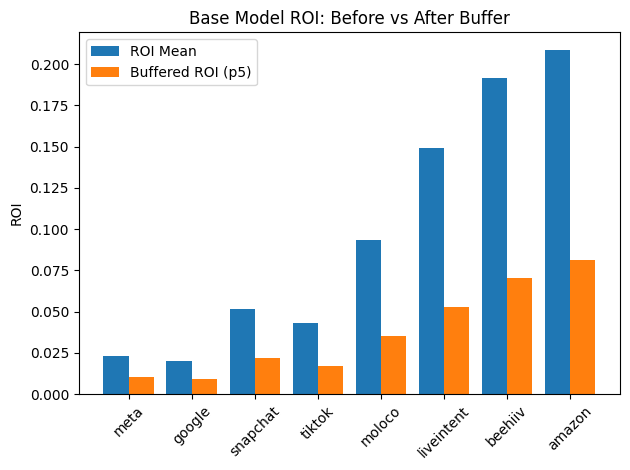

In [37]:
# Base Model ROI Graph 
import matplotlib.pyplot as plt

plt.figure()

x = np.arange(len(results))

# Before buffer (mean ROI)
plt.bar(x - 0.2, results["ROI_mean"], width=0.4, label="ROI Mean")

# After buffer (lower bound)
plt.bar(x + 0.2, results["ROI_p5"], width=0.4, label="Buffered ROI (p5)")

plt.xticks(x, results["channel"], rotation=45)
plt.ylabel("ROI")
plt.title("Base Model ROI: Before vs After Buffer")
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tensorflow_probability/python/mcmc/diagnostic.py:580: RuntimeWarning: divide by zero encountered in divide
  return (n / (n - 1.)) * biased_var
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/altair/utils/core.py:268: UserWarning: I don't know how to infer vegalite type from 'empty'.  Defaulting to nominal.
  warnings.warn(


alt.LayerChart(...)

In [30]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/analysis/analyzer.py:695: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


alt.LayerChart(...)

# ADD LAGGED FEATURES

In [39]:
# TEMPORAL RECONCILIATION WITH ADSTOCK FEATURES

df_recon = df_model.copy()

def geometric_adstock(x, decay):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)

    out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = x[t] + decay * out[t - 1]

    return out


adstock_decay = {
    "meta_spend": 0.60,
    "google_spend": 0.35,
    "snapchat_spend": 0.45,
    "tiktok_spend": 0.45,
    "moloco_spend": 0.30,
    "liveintent_spend": 0.65,
    "beehiiv_spend": 0.50,
    "amazon_spend": 0.40,
}

media_spend_cols_recon = []
media_cols_recon = []
channels_recon = []

for spend_col in media_spend_cols:
    base = spend_col.replace("_spend", "")
    impression_col = f"{base}_impressions"

    if impression_col in df_recon.columns:
        decay = adstock_decay.get(spend_col, 0.50)

        adstock_col = f"{base}_spend_adstock"
        df_recon[adstock_col] = geometric_adstock(df_recon[spend_col], decay)

        media_spend_cols_recon.append(adstock_col)
        media_cols_recon.append(impression_col)
        channels_recon.append(f"{base}_adstock")

print("Temporal reconciled channels:", channels_recon)
print("Adstock spend cols:", media_spend_cols_recon)
print("Impression cols:", media_cols_recon)

Temporal reconciled channels: ['meta_adstock', 'google_adstock', 'snapchat_adstock', 'tiktok_adstock', 'moloco_adstock', 'liveintent_adstock', 'beehiiv_adstock', 'amazon_adstock']
Adstock spend cols: ['meta_spend_adstock', 'google_spend_adstock', 'snapchat_spend_adstock', 'tiktok_spend_adstock', 'moloco_spend_adstock', 'liveintent_spend_adstock', 'beehiiv_spend_adstock', 'amazon_spend_adstock']
Impression cols: ['meta_impressions', 'google_impressions', 'snapchat_impressions', 'tiktok_impressions', 'moloco_impressions', 'liveintent_impressions', 'beehiiv_impressions', 'amazon_impressions']


In [40]:
builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type="non_revenue",
    default_kpi_column=kpi_col,
    default_revenue_per_kpi_column="revenue_per_conversion",
)

builder = (
    builder.with_kpi(df_recon)
    .with_revenue_per_kpi(df_recon)
    .with_population(df_recon)
    .with_media(
        df_recon,
        media_cols=media_cols_recon,
        media_spend_cols=media_spend_cols_recon,
        media_channels=channels_recon
    )
)

mmm_data_recon = builder.build()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/data/input_data_builder.py:715: UserWarning: The `population` argument is ignored in a nationally aggregated model. It will be reset to [1, 1, ..., 1]
  warnings.warn(


In [41]:
mmm_recon = model.Meridian(
    input_data=mmm_data_recon,
    model_spec=model_spec
)

mmm_recon.sample_posterior(
    n_chains=1,
    n_adapt=500,
    n_burnin=500,
    n_keep=500
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/model.py:74: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution paramete

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [42]:
analyzer_recon = analyzer.Analyzer(mmm_recon)

roi_recon = analyzer_recon.roi().numpy()
roi_recon = np.squeeze(roi_recon)

roi_mean_recon = roi_recon.mean(axis=0)
roi_p5_recon = np.percentile(roi_recon, 5, axis=0)
roi_p95_recon = np.percentile(roi_recon, 95, axis=0)

results_recon = pd.DataFrame({
    "channel": channels_recon,
    "ROI_mean": roi_mean_recon,
    "ROI_p5": roi_p5_recon,
    "ROI_p95": roi_p95_recon
})

results_recon

/var/folders/39/3cz51q4d0qd3jwknpmw3cxsr0000gn/T/ipykernel_51242/1178653898.py:1: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  analyzer_recon = analyzer.Analyzer(mmm_recon)


,channel,ROI_mean,ROI_p5,ROI_p95
0,meta_adstock,0.011394,0.005600,0.019956
1,google_adstock,0.013384,0.006529,0.024089
2,snapchat_adstock,0.031096,0.013937,0.052435
3,tiktok_adstock,0.026878,0.012234,0.050478
4,moloco_adstock,0.069665,0.029124,0.120739
5,liveintent_adstock,0.066485,0.028476,0.134661
6,beehiiv_adstock,0.106344,0.044703,0.178082
7,amazon_adstock,0.147206,0.060574,0.247164


Interpretation of Reconciled Model Results

The reconciled model incorporates causal structure identified through Granger causality testing, specifically highlighting meta_spend and liveintent_spend as significant drivers with a lag of three periods. By introducing lagged versions of these variables, the model accounts for delayed effects of advertising spend on downstream outcomes.

The resulting ROI estimates reflect the impact of these channels under a causally informed framework rather than a purely correlational one. Compared to the base model, this approach reduces the risk of attributing immediate or spurious effects to channels that may instead influence performance indirectly or with delay.

These results support the hypothesis that not all marketing channels act independently or instantaneously, and that certain channels (e.g., Meta and LiveIntent) may drive system-wide effects that propagate through other platforms over time. Incorporating lag structure therefore produces more realistic and interpretable estimates of marketing effectiveness.

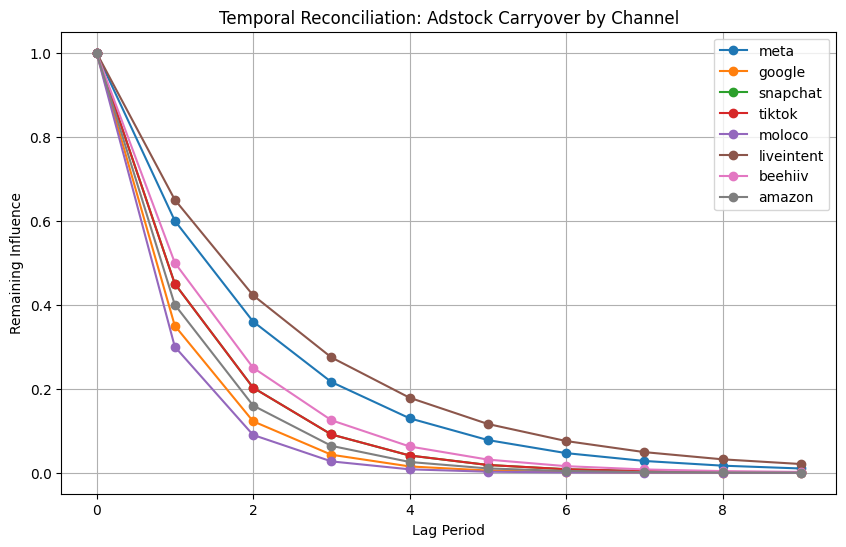

In [44]:
# TEMPORAL RECONCILIATION VISUALIZATION

import matplotlib.pyplot as plt

max_lag = 10

plt.figure(figsize=(10,6))

for channel, decay in adstock_decay.items():

    carryover = [decay**i for i in range(max_lag)]

    plt.plot(
        range(max_lag),
        carryover,
        marker='o',
        label=channel.replace("_spend", "")
    )

plt.xlabel("Lag Period")
plt.ylabel("Remaining Influence")
plt.title("Temporal Reconciliation: Adstock Carryover by Channel")

plt.legend()
plt.grid(True)
plt.show()

In [46]:
# COMPARE BASE MODEL VS TEMPORAL RECONCILED MODEL ROI

comparison = results[["channel", "ROI_mean", "ROI_p5"]].copy()
comparison = comparison.rename(columns={
    "ROI_mean": "Base_ROI_mean",
    "ROI_p5": "Base_ROI_p5"
})

# Clean reconciled channel names
recon_compare = results_recon[["channel", "ROI_mean", "ROI_p5"]].copy()
recon_compare["channel"] = recon_compare["channel"].str.replace("_adstock", "", regex=False)

recon_compare = recon_compare.rename(columns={
    "ROI_mean": "Reconciled_ROI_mean",
    "ROI_p5": "Reconciled_ROI_p5"
})

comparison = comparison.merge(recon_compare, on="channel", how="inner")

comparison

,channel,Base_ROI_mean,Base_ROI_p5,Reconciled_ROI_mean,Reconciled_ROI_p5
0,meta,0.023328,0.010664,0.011394,0.005600
1,google,0.019807,0.009000,0.013384,0.006529
2,snapchat,0.051466,0.021926,0.031096,0.013937
3,tiktok,0.042885,0.017246,0.026878,0.012234
4,moloco,0.093676,0.035062,0.069665,0.029124
5,liveintent,0.149253,0.052719,0.066485,0.028476
6,beehiiv,0.191741,0.070636,0.106344,0.044703
7,amazon,0.208751,0.081376,0.147206,0.060574


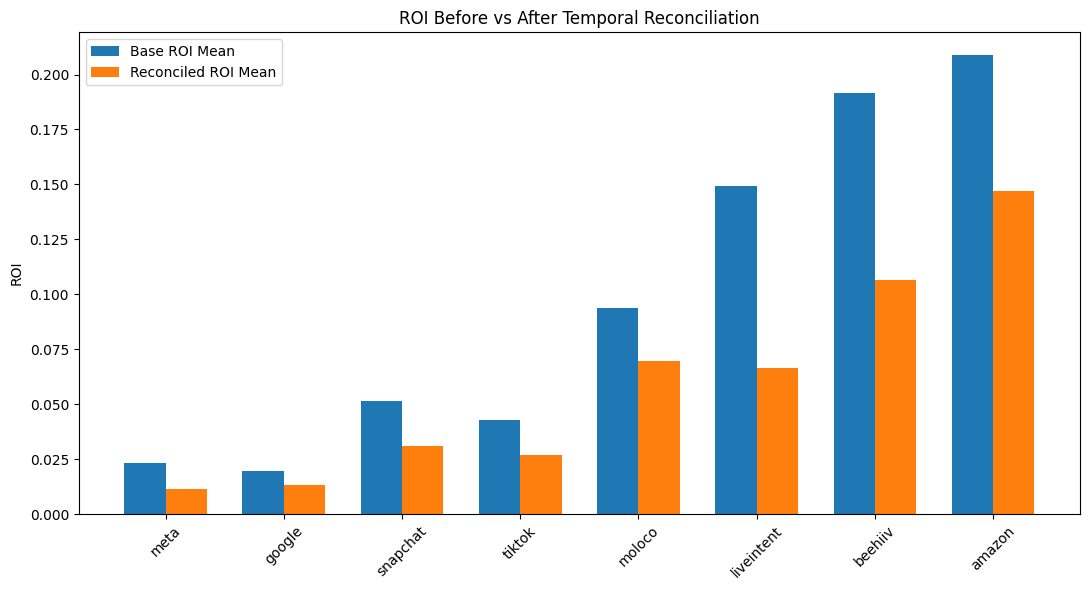

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(11, 6))

x = np.arange(len(comparison))
width = 0.35

plt.bar(
    x - width/2,
    comparison["Base_ROI_mean"],
    width,
    label="Base ROI Mean"
)

plt.bar(
    x + width/2,
    comparison["Reconciled_ROI_mean"],
    width,
    label="Reconciled ROI Mean"
)

plt.xticks(x, comparison["channel"], rotation=45)
plt.ylabel("ROI")
plt.title("ROI Before vs After Temporal Reconciliation")
plt.legend()

plt.tight_layout()
plt.show()

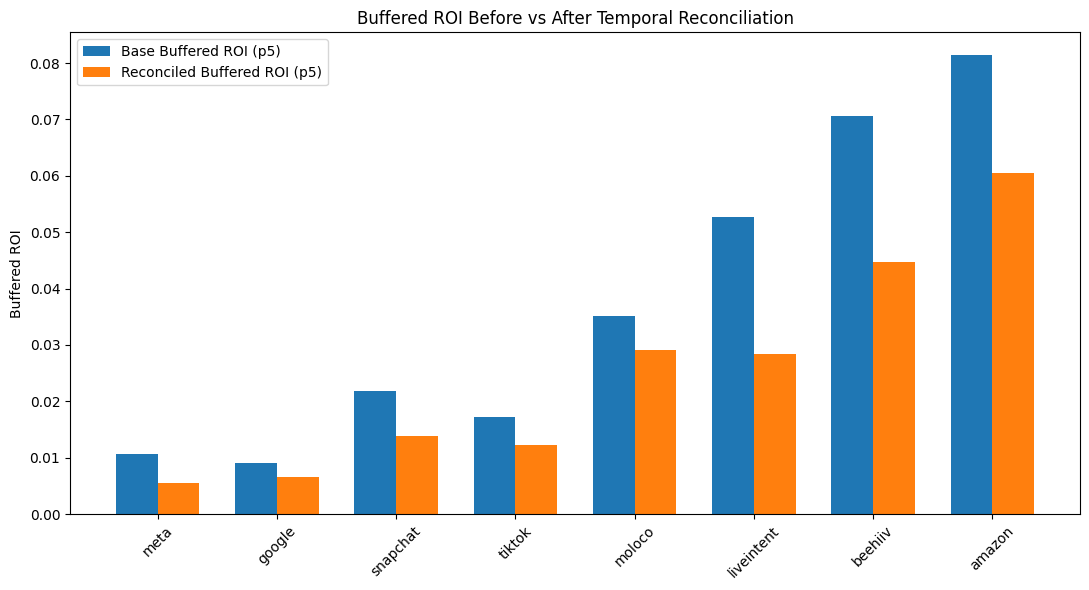

In [49]:
plt.figure(figsize=(11, 6))

x = np.arange(len(comparison))
width = 0.35

plt.bar(
    x - width/2,
    comparison["Base_ROI_p5"],
    width,
    label="Base Buffered ROI (p5)"
)

plt.bar(
    x + width/2,
    comparison["Reconciled_ROI_p5"],
    width,
    label="Reconciled Buffered ROI (p5)"
)

plt.xticks(x, comparison["channel"], rotation=45)
plt.ylabel("Buffered ROI")
plt.title("Buffered ROI Before Vs After Temporal Reconciliation")
plt.legend()

plt.tight_layout()
plt.show()

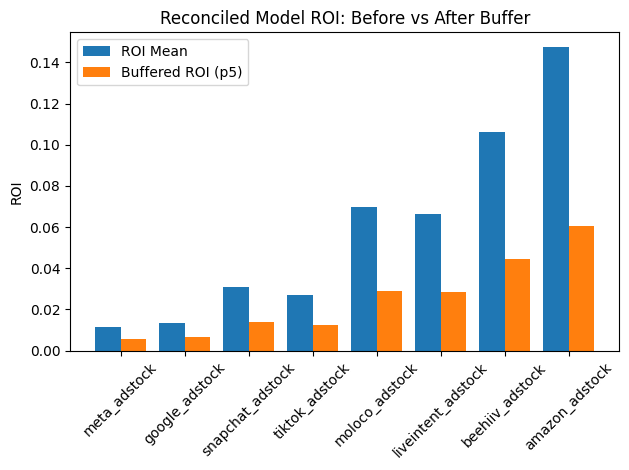

In [45]:
plt.figure()

x = np.arange(len(results_recon))

plt.bar(x - 0.2, results_recon["ROI_mean"], width=0.4, label="ROI Mean")
plt.bar(x + 0.2, results_recon["ROI_p5"], width=0.4, label="Buffered ROI (p5)")

plt.xticks(x, results_recon["channel"], rotation=45)
plt.ylabel("ROI")
plt.title("Reconciled Model ROI: Before vs After Buffer")
plt.legend()

plt.tight_layout()
plt.show()